# Capítulo 03. Teoría del cambio, mecanismos e indicadores

Este cuaderno usa datos simulados para enseñar cómo documentar una teoría del cambio y un conjunto de indicadores de monitoreo. No contiene datos reales ni permite hacer afirmaciones causales.

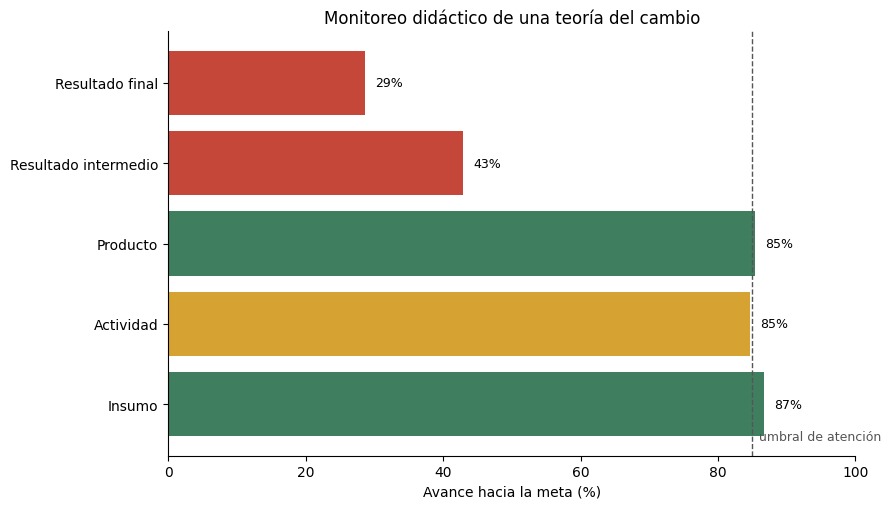

,eslabon,componente,mecanismo,supuesto_critico
0,Insumo,Presupuesto para tutores,Aumenta la capacidad de apoyo académico,La contratación ocurre antes del inicio del pe...
1,Actividad,Tutorías semanales,Reduce rezagos de aprendizaje y mejora expecta...,Los estudiantes asisten y los horarios son com...
2,Producto,Estudiantes atendidos,La población objetivo recibe apoyo de forma ef...,El registro de atención es completo y verificable
3,Resultado intermedio,Asistencia mensual,Mayor asistencia aumenta exposición al aprendi...,No hay barreras externas dominantes como inseg...
4,Resultado final,Permanencia escolar,Mejor desempeño y continuidad reducen abandono,El seguimiento cubre todo el ciclo escolar


,indicador,eslabon,unidad_analisis,fuente_potencial,frecuencia,linea_base,valor_observado,meta,avance_hacia_meta,brecha_meta,estado
0,Porcentaje de presupuesto comprometido,Insumo,programa-mes,registro presupuestario,mensual,0.00,0.78,0.90,0.866667,0.12,Cerca de meta
1,Tutorías ejecutadas sobre planificadas,Actividad,sede-mes,registro operativo,mensual,0.00,0.72,0.85,0.847059,0.13,En seguimiento
2,Estudiantes con al menos cuatro tutorías,Producto,estudiante-mes,registro de atención,mensual,0.00,0.64,0.75,0.853333,0.11,Cerca de meta
3,Asistencia mensual promedio,Resultado intermedio,estudiante-mes,registro de asistencia,mensual,0.68,0.74,0.82,0.428571,0.08,Rezago
4,Permanencia escolar anual,Resultado final,estudiante-año,registro educativo autorizado,anual,0.81,0.83,0.88,0.285714,0.05,Rezago


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


BOOK_SLUG = "politicas_publicas_basadas_en_datos"


def find_book_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        direct = path
        nested = path / "books" / BOOK_SLUG
        if (direct / "chapters" / "01_decisiones_publicas_basadas_en_datos.md").exists():
            return direct
        if (nested / "chapters" / "01_decisiones_publicas_basadas_en_datos.md").exists():
            return nested
    raise FileNotFoundError("No se encontró la raíz del libro.")


book_root = find_book_root()
tables_dir = book_root / "outputs" / "tables"
figures_dir = book_root / "outputs" / "figures"
reports_dir = book_root / "outputs" / "reports"
for directory in [tables_dir, figures_dir, reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)

teoria_cambio = pd.DataFrame(
    [
        {
            "eslabon": "Insumo",
            "componente": "Presupuesto para tutores",
            "mecanismo": "Aumenta la capacidad de apoyo académico",
            "supuesto_critico": "La contratación ocurre antes del inicio del periodo escolar",
        },
        {
            "eslabon": "Actividad",
            "componente": "Tutorías semanales",
            "mecanismo": "Reduce rezagos de aprendizaje y mejora expectativas de aprobación",
            "supuesto_critico": "Los estudiantes asisten y los horarios son compatibles",
        },
        {
            "eslabon": "Producto",
            "componente": "Estudiantes atendidos",
            "mecanismo": "La población objetivo recibe apoyo de forma efectiva",
            "supuesto_critico": "El registro de atención es completo y verificable",
        },
        {
            "eslabon": "Resultado intermedio",
            "componente": "Asistencia mensual",
            "mecanismo": "Mayor asistencia aumenta exposición al aprendizaje",
            "supuesto_critico": "No hay barreras externas dominantes como inseguridad o trabajo infantil",
        },
        {
            "eslabon": "Resultado final",
            "componente": "Permanencia escolar",
            "mecanismo": "Mejor desempeño y continuidad reducen abandono",
            "supuesto_critico": "El seguimiento cubre todo el ciclo escolar",
        },
    ]
)

indicadores = pd.DataFrame(
    [
        {
            "indicador": "Porcentaje de presupuesto comprometido",
            "eslabon": "Insumo",
            "unidad_analisis": "programa-mes",
            "fuente_potencial": "registro presupuestario",
            "frecuencia": "mensual",
            "linea_base": 0.0,
            "valor_observado": 0.78,
            "meta": 0.90,
        },
        {
            "indicador": "Tutorías ejecutadas sobre planificadas",
            "eslabon": "Actividad",
            "unidad_analisis": "sede-mes",
            "fuente_potencial": "registro operativo",
            "frecuencia": "mensual",
            "linea_base": 0.0,
            "valor_observado": 0.72,
            "meta": 0.85,
        },
        {
            "indicador": "Estudiantes con al menos cuatro tutorías",
            "eslabon": "Producto",
            "unidad_analisis": "estudiante-mes",
            "fuente_potencial": "registro de atención",
            "frecuencia": "mensual",
            "linea_base": 0.0,
            "valor_observado": 0.64,
            "meta": 0.75,
        },
        {
            "indicador": "Asistencia mensual promedio",
            "eslabon": "Resultado intermedio",
            "unidad_analisis": "estudiante-mes",
            "fuente_potencial": "registro de asistencia",
            "frecuencia": "mensual",
            "linea_base": 0.68,
            "valor_observado": 0.74,
            "meta": 0.82,
        },
        {
            "indicador": "Permanencia escolar anual",
            "eslabon": "Resultado final",
            "unidad_analisis": "estudiante-año",
            "fuente_potencial": "registro educativo autorizado",
            "frecuencia": "anual",
            "linea_base": 0.81,
            "valor_observado": 0.83,
            "meta": 0.88,
        },
    ]
)

indicadores["avance_hacia_meta"] = (
    (indicadores["valor_observado"] - indicadores["linea_base"])
    / (indicadores["meta"] - indicadores["linea_base"])
).clip(lower=0, upper=1)
indicadores["brecha_meta"] = indicadores["meta"] - indicadores["valor_observado"]
indicadores["estado"] = pd.cut(
    indicadores["avance_hacia_meta"],
    bins=[-0.01, 0.60, 0.85, 1.00],
    labels=["Rezago", "En seguimiento", "Cerca de meta"],
)

teoria_cambio.to_csv(tables_dir / "chapter_03_matriz_teoria_cambio.csv", index=False)
indicadores.to_csv(tables_dir / "chapter_03_indicadores_monitoreo.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.2))
colors = indicadores["estado"].map(
    {"Rezago": "#c4473a", "En seguimiento": "#d6a232", "Cerca de meta": "#3f7f5f"}
)
ax.barh(indicadores["eslabon"], indicadores["avance_hacia_meta"] * 100, color=colors)
ax.set_xlim(0, 100)
ax.set_xlabel("Avance hacia la meta (%)")
ax.set_title("Monitoreo didáctico de una teoría del cambio")
ax.axvline(85, color="#555555", linewidth=1, linestyle="--")
ax.text(86, -0.45, "umbral de atención", fontsize=9, color="#555555")
for index, value in enumerate(indicadores["avance_hacia_meta"] * 100):
    ax.text(value + 1.5, index, f"{value:.0f}%", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(figures_dir / "chapter_03_avance_indicadores.png", dpi=180)
plt.show()

nota = """# Nota metodológica - Capítulo 03

Los datos de este cuaderno son simulados. Sirven para practicar la construcción de una matriz de teoría del cambio, indicadores, metas y semáforos de monitoreo.

No deben interpretarse como evidencia de un programa real, ni como estimación de impacto causal. Para una aplicación institucional se requiere fuente autorizada, diccionario de variables, línea base, periodo, cobertura, validación de calidad y revisión ética.
"""
(reports_dir / "chapter_03_nota_metodologica.md").write_text(nota, encoding="utf-8")

display(teoria_cambio)
display(indicadores)
